Imports & Global Params

In [75]:
import duckdb
import numpy as np
import pandas as pd
import igraph as ig

import matplotlib.pyplot as plt
import seaborn as sns

import mord
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from lightgbm import LGBMClassifier

np.random.seed(42)
plt.style.use("seaborn-v0_8")


Time Windows & Constants

In [76]:
graph_end_date = '2024-08-31'
block_window_start = '2024-09-01'
block_window_end   = '2024-09-30'

behavior_window_len = 30
min_blocks = 3

con = duckdb.connect()


Identify Heavy Blockers

In [77]:
con.execute(f"""
CREATE OR REPLACE TEMP TABLE heavy_blockers AS
SELECT did_id
FROM read_parquet('blocks.parquet')
WHERE created_date BETWEEN DATE '{block_window_start}' - INTERVAL 1 MONTH
                       AND DATE '{block_window_start}' - INTERVAL 1 DAY
GROUP BY did_id
HAVING COUNT(*) >= {min_blocks}
""")

num_blockers = con.execute(
    "SELECT COUNT(*) FROM heavy_blockers"
).fetchone()[0]

print(f"Number of heavy blockers: {num_blockers}")


Number of heavy blockers: 36343


Graph Construction

In [78]:
con.execute(f"""
CREATE OR REPLACE TEMP TABLE reply_edges AS
SELECT DISTINCT
    p.did_id AS src,
    p.reply_parent_did_id AS dst
FROM read_parquet('posts.parquet') p
JOIN heavy_blockers b1 ON p.did_id = b1.did_id
JOIN heavy_blockers b2 ON p.reply_parent_did_id = b2.did_id
WHERE p.reply_parent_did_id IS NOT NULL
  AND p.created_date <= DATE '{graph_end_date}'
""")

edges = con.execute("""
SELECT src, dst
FROM reply_edges
WHERE src IS NOT NULL
  AND dst IS NOT NULL
  AND src != dst
""").fetchdf()

g = ig.Graph.TupleList(
    edges.itertuples(index=False),
    directed=True
)

g.simplify(multiple=True, loops=True)
print(g.summary())


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

IGRAPH DN-- 29669 2678790 -- 
+ attr: name (v)


Graph Features

In [79]:
g.vs["out_degree"] = g.outdegree()
g.vs["in_degree"]  = g.indegree()
g.vs["pagerank"]   = g.pagerank()
g.vs["core"]       = g.coreness()

g_und = g.as_undirected()
g.vs["clustering"] = g_und.transitivity_local_undirected(mode="zero")

avg_deg = []
for v in g_und.vs:
    neigh = v.neighbors()
    avg_deg.append(np.mean([n.degree() for n in neigh]) if neigh else 0)

g.vs["avg_neighbor_degree"] = avg_deg


Community detection

In [80]:
communities = g_und.community_leiden(
    objective_function="modularity",
    resolution=1.0
)

g.vs["community"] = communities.membership
print("Number of communities:", len(set(communities.membership)))


Number of communities: 250


In [81]:
graph_features = pd.DataFrame({
    "did_id": g.vs["name"],
    "community": g.vs["community"],
    "out_degree": g.vs["out_degree"],
    "in_degree": g.vs["in_degree"],
    "pagerank": g.vs["pagerank"],
    "core": g.vs["core"],
    "clustering": g.vs["clustering"],
    "avg_neighbor_degree": g.vs["avg_neighbor_degree"]
})


Behavioral Features

In [83]:
# Posts
post_counts = con.execute(f"""
SELECT did_id, COUNT(*) AS post_count
FROM read_parquet('posts.parquet')
WHERE created_date <= DATE '{graph_end_date}'
GROUP BY did_id
""").fetchdf()

# Replies (subset of posts)
reply_counts = con.execute(f"""
SELECT did_id, COUNT(*) AS reply_count
FROM read_parquet('posts.parquet')
WHERE reply_parent_did_id IS NOT NULL
  AND created_date <= DATE '{graph_end_date}'
GROUP BY did_id
""").fetchdf()

# Likes
like_counts = con.execute(f"""
SELECT did_id, COUNT(*) AS like_count
FROM read_parquet('likes.parquet')
WHERE created_date <= DATE '{graph_end_date}'
GROUP BY did_id
""").fetchdf()

# Reposts
repost_counts = con.execute(f"""
SELECT did_id, COUNT(*) AS repost_count
FROM read_parquet('reposts.parquet')
WHERE created_date <= DATE '{graph_end_date}'
GROUP BY did_id
""").fetchdf()

# Merge all behavioral counts
behavior_df = (
    post_counts
    .merge(reply_counts, on="did_id", how="left")
    .merge(like_counts, on="did_id", how="left")
    .merge(repost_counts, on="did_id", how="left")
)

behavior_df.fillna(0, inplace=True)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [84]:
past_blocks_df = con.execute(f"""
SELECT
    did_id,
    COUNT(*) AS past_blocks
FROM read_parquet('blocks.parquet')
WHERE created_date < DATE '{block_window_start}'
GROUP BY did_id
""").fetchdf()


In [85]:
df = (
    graph_features
    .merge(behavior_df, on="did_id", how="left")
    .merge(past_blocks_df, on="did_id", how="left")
)

df.fillna(0, inplace=True)


Community features

In [86]:
df["posts_per_day"] = df["post_count"] / behavior_window_len
df["reply_ratio"] = df["reply_count"] / (df["post_count"] + 5)

community_stats = (
    df.groupby("community")
      .agg(
          community_size=("did_id", "count"),
          mean_past_blocks=("past_blocks", "mean"),
          median_past_blocks=("past_blocks", "median"),
          frac_prior_heavy_blockers=(
              "past_blocks",
              lambda x: (x >= min_blocks).mean()
          ),
          mean_reply_ratio=("reply_ratio", "mean"),
          mean_posts_per_day=("posts_per_day", "mean")
      )
      .reset_index()
)

df = df.merge(community_stats, on="community", how="left")

df["rel_out_degree"] = (
    df["out_degree"] /
    (df.groupby("community")["out_degree"].transform("mean") + 1e-3)
)


Labels

In [87]:
label_df = con.execute(f"""
SELECT did_id, COUNT(*) AS future_blocks
FROM read_parquet('blocks.parquet')
WHERE created_date BETWEEN DATE '{block_window_start}'
                      AND DATE '{block_window_end}'
GROUP BY did_id
""").fetchdf()

df = df.merge(label_df, on="did_id", how="left")
df["future_blocks"] = df["future_blocks"].fillna(0)

def block_class(x):
    if x <= 5:
        return 0
    elif x <= 15:
        return 1
    else:
        return 2

df["block_class"] = df["future_blocks"].apply(block_class)


In [88]:
FEATURE_BASE = [
    'out_degree','in_degree','pagerank','core',
    'clustering','avg_neighbor_degree',
    'post_count','reply_count','like_count','repost_count',
    # community
    'community_size','mean_past_blocks','median_past_blocks',
    'frac_prior_heavy_blockers','mean_reply_ratio',
    'mean_posts_per_day','rel_out_degree'
]

X = df[FEATURE_BASE].copy()
y = df["block_class"]


Merging Tables

In [89]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


Define Target

In [90]:
def engineer_features(df):
    df = df.copy()

    df["posts_per_day"]   = df["post_count"] / behavior_window_len
    df["replies_per_day"] = df["reply_count"] / behavior_window_len

    df["reply_ratio"]  = df["reply_count"]  / (df["post_count"] + 5)
    df["like_ratio"]   = df["like_count"]   / (df["post_count"] + 5)
    df["repost_ratio"] = df["repost_count"] / (df["post_count"] + 5)

    df["in_out_ratio"] = df["in_degree"] / (df["out_degree"] + 1)

    LOG_COLS = [
        'out_degree','in_degree','avg_neighbor_degree',
        'post_count','reply_count','like_count','repost_count',
        'posts_per_day','replies_per_day'
    ]

    for c in LOG_COLS:
        df[c] = np.log1p(df[c])

    return df

X_train = engineer_features(X_train)
X_val   = engineer_features(X_val)


In [91]:
corr = X_train.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [c for c in upper.columns if any(upper[c] > 0.85)]
print("Dropped:", to_drop)

X_train = X_train.drop(columns=to_drop)
X_val   = X_val.drop(columns=to_drop)


Dropped: ['in_degree', 'core', 'reply_count', 'median_past_blocks', 'posts_per_day', 'replies_per_day']


Feature engineering on train data only

In [92]:
rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=12,
    min_samples_leaf=30,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)

print(classification_report(y_val, y_pred_rf))


              precision    recall  f1-score   support

           0       0.49      0.50      0.49      1977
           1       0.35      0.31      0.33      1717
           2       0.55      0.59      0.57      2240

    accuracy                           0.48      5934
   macro avg       0.46      0.47      0.46      5934
weighted avg       0.47      0.48      0.47      5934



In [93]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
cw = dict(enumerate(class_weights))

lgbm = LGBMClassifier(
    objective="multiclassova",
    num_class=3,
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=63,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight=cw,
    random_state=42
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="multi_logloss",
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

y_pred_lgbm = lgbm.predict(X_val)
print(classification_report(y_val, y_pred_lgbm))


[LightGBM] [Info] Number of positive: 7906, number of negative: 15829
[LightGBM] [Info] Number of positive: 6869, number of negative: 16866
[LightGBM] [Info] Number of positive: 8960, number of negative: 14775
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001632 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3448
[LightGBM] [Info] Number of data points in the train set: 23735, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333333 -> initscore=-0.693147
[LightGBM] [Info] Start training from score -0.693147
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333333 -> initscore=-0.693147
[LightGBM] [Info] Start training from score -0.693147
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333333 -> initscore=-0.693147
[LightGBM] [Info] Start training from score -0.693147
              precision    recall  f1-score   support

           0       0.49      0.50      0.49 

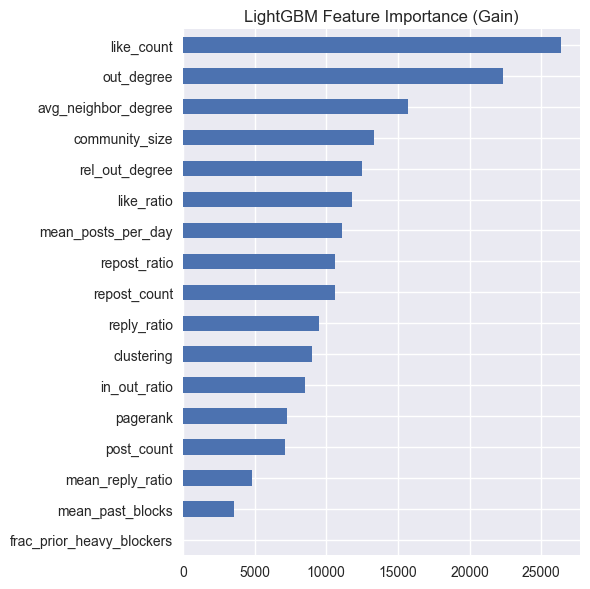

In [94]:
pd.Series(
    lgbm.booster_.feature_importance(importance_type="gain"),
    index=X_train.columns
).sort_values().plot(kind="barh", figsize=(6,6))

plt.title("LightGBM Feature Importance (Gain)")
plt.tight_layout()
plt.show()


Testing on crawled data

In [148]:
NEW_DATA_PATH = "crawledData"

In [149]:
con.execute(f"""
SELECT
    MIN(CAST(created_date AS DATE)) AS min_date,
    MAX(CAST(created_date AS DATE)) AS max_date
FROM read_parquet('{NEW_DATA_PATH}/blocks.parquet')
""").fetchdf()


,min_date,max_date
0,2025-12-31,2026-01-17


In [150]:
EVAL_GRAPH_START = "2025-12-31"
EVAL_GRAPH_END   = "2026-01-09"

EVAL_BLOCK_START = "2026-01-10"
EVAL_BLOCK_END   = "2026-01-17"


In [154]:
con.execute(f"""
CREATE OR REPLACE TEMP TABLE eval_heavy_blockers AS
SELECT did_id
FROM read_parquet('{NEW_DATA_PATH}/blocks.parquet')
WHERE CAST(created_date AS DATE)
      BETWEEN DATE '{EVAL_BLOCK_START}' - INTERVAL 1 MONTH
          AND DATE '{EVAL_BLOCK_START}' - INTERVAL 1 DAY
  AND did_id != 1
GROUP BY did_id
""")

num_eval_blockers = con.execute(
    "SELECT COUNT(*) FROM eval_heavy_blockers"
).fetchone()[0]

print(f"Number of eval heavy blockers: {num_eval_blockers}")


Number of eval heavy blockers: 36545


In [156]:
con.execute(f"""
CREATE OR REPLACE TEMP TABLE eval_reply_edges AS
SELECT DISTINCT
    p.did_id AS src,
    p.reply_parent_did_id AS dst
FROM read_parquet('{NEW_DATA_PATH}/posts.parquet') p
JOIN eval_heavy_blockers b1 ON p.did_id = b1.did_id
JOIN eval_heavy_blockers b2 ON p.reply_parent_did_id = b2.did_id
WHERE p.reply_parent_did_id IS NOT NULL
  AND p.did_id != 1
  AND p.reply_parent_did_id != 1
  AND CAST(p.created_date AS DATE)
      BETWEEN DATE '{EVAL_GRAPH_START}'
          AND DATE '{EVAL_GRAPH_END}'
""")
con.execute(f"""
CREATE OR REPLACE TEMP TABLE eval_follow_edges AS
SELECT DISTINCT
    f.did_id AS src,
    f.subject_did_id AS dst
FROM read_parquet('{NEW_DATA_PATH}/follows.parquet') f
JOIN eval_heavy_blockers b1 ON f.did_id = b1.did_id
JOIN eval_heavy_blockers b2 ON f.subject_did_id = b2.did_id
WHERE f.did_id != 1
  AND f.subject_did_id != 1
  AND CAST(f.created_date AS DATE)
      <= DATE '{EVAL_GRAPH_END}'
""")
con.execute(f"""
CREATE OR REPLACE TEMP TABLE eval_repost_edges AS
SELECT DISTINCT
    r.did_id AS src,
    r.subject_did_id AS dst
FROM read_parquet('{NEW_DATA_PATH}/reposts.parquet') r
JOIN eval_heavy_blockers b1 ON r.did_id = b1.did_id
JOIN eval_heavy_blockers b2 ON r.subject_did_id = b2.did_id
WHERE r.did_id != 1
  AND r.subject_did_id != 1
  AND CAST(r.created_date AS DATE)
      BETWEEN DATE '{EVAL_GRAPH_START}'
          AND DATE '{EVAL_GRAPH_END}'
""")
con.execute("""
CREATE OR REPLACE TEMP TABLE eval_interaction_edges AS
SELECT src, dst FROM eval_reply_edges
UNION
SELECT src, dst FROM eval_follow_edges
UNION
SELECT src, dst FROM eval_repost_edges
""")

edges_eval = con.execute("""
SELECT src, dst
FROM eval_interaction_edges
WHERE src IS NOT NULL
  AND dst IS NOT NULL
  AND src != dst
""").fetchdf()

print("Eval edges shape:", edges_eval.shape)

g_eval = ig.Graph.TupleList(
    edges_eval.itertuples(index=False),
    directed=True
)

g_eval.simplify(multiple=True, loops=True)
print(g_eval.summary())


Eval edges shape: (1697, 2)
IGRAPH DN-- 2166 1697 -- 
+ attr: name (v)


In [157]:
g_eval.vs["out_degree"] = g_eval.outdegree()
g_eval.vs["in_degree"]  = g_eval.indegree()
g_eval.vs["pagerank"]   = g_eval.pagerank()
g_eval.vs["core"]       = g_eval.coreness()

g_eval_und = g_eval.as_undirected()
g_eval.vs["clustering"] = g_eval_und.transitivity_local_undirected(mode="zero")

avg_deg = []
for v in g_eval_und.vs:
    neigh = v.neighbors()
    avg_deg.append(np.mean([n.degree() for n in neigh]) if neigh else 0)

g_eval.vs["avg_neighbor_degree"] = avg_deg


In [158]:
communities = g_eval_und.community_leiden(
    objective_function="modularity",
    resolution=1.0
)

g_eval.vs["community"] = communities.membership
print("Number of communities:", len(set(communities.membership)))


Number of communities: 547


In [159]:
graph_eval = pd.DataFrame({
    "did_id": g_eval.vs["name"],
    "community": g_eval.vs["community"],
    "out_degree": g_eval.vs["out_degree"],
    "in_degree": g_eval.vs["in_degree"],
    "pagerank": g_eval.vs["pagerank"],
    "core": g_eval.vs["core"],
    "clustering": g_eval.vs["clustering"],
    "avg_neighbor_degree": g_eval.vs["avg_neighbor_degree"]
})


In [161]:
post_eval = con.execute(f"""
SELECT did_id, COUNT(*) AS post_count
FROM read_parquet('{NEW_DATA_PATH}/posts.parquet')
WHERE did_id != 1
  AND CAST(created_date AS DATE)
      BETWEEN DATE '{EVAL_GRAPH_START}'
          AND DATE '{EVAL_GRAPH_END}'
GROUP BY did_id
""").fetchdf()

reply_eval = con.execute(f"""
SELECT did_id, COUNT(*) AS reply_count
FROM read_parquet('{NEW_DATA_PATH}/posts.parquet')
WHERE reply_parent_did_id IS NOT NULL
  AND did_id != 1
  AND CAST(created_date AS DATE)
      BETWEEN DATE '{EVAL_GRAPH_START}'
          AND DATE '{EVAL_GRAPH_END}'
GROUP BY did_id
""").fetchdf()

like_eval = con.execute(f"""
SELECT did_id, COUNT(*) AS like_count
FROM read_parquet('{NEW_DATA_PATH}/likes.parquet')
WHERE did_id != 1
  AND CAST(created_date AS DATE)
      BETWEEN DATE '{EVAL_GRAPH_START}'
          AND DATE '{EVAL_GRAPH_END}'
GROUP BY did_id
""").fetchdf()

repost_eval = con.execute(f"""
SELECT did_id, COUNT(*) AS repost_count
FROM read_parquet('{NEW_DATA_PATH}/reposts.parquet')
WHERE did_id != 1
  AND CAST(created_date AS DATE)
      BETWEEN DATE '{EVAL_GRAPH_START}'
          AND DATE '{EVAL_GRAPH_END}'
GROUP BY did_id
""").fetchdf()

behavior_eval = (
    post_eval
    .merge(reply_eval, on="did_id", how="left")
    .merge(like_eval, on="did_id", how="left")
    .merge(repost_eval, on="did_id", how="left")
)

behavior_eval.fillna(0, inplace=True)


In [162]:
past_blocks_eval = con.execute(f"""
SELECT did_id, COUNT(*) AS past_blocks
FROM read_parquet('{NEW_DATA_PATH}/blocks.parquet')
WHERE did_id != 1
  AND CAST(created_date AS DATE) < DATE '{EVAL_BLOCK_START}'
GROUP BY did_id
""").fetchdf()


In [163]:
df_eval = (
    graph_eval
    .merge(behavior_eval, on="did_id", how="left")
    .merge(past_blocks_eval, on="did_id", how="left")
)

df_eval.fillna(0, inplace=True)


In [164]:
df_eval["posts_per_day"] = df_eval["post_count"] / behavior_window_len
df_eval["reply_ratio"] = df_eval["reply_count"] / (df_eval["post_count"] + 5)

community_stats_eval = (
    df_eval.groupby("community")
      .agg(
          community_size=("did_id", "count"),
          mean_past_blocks=("past_blocks", "mean"),
          median_past_blocks=("past_blocks", "median"),
          frac_prior_heavy_blockers=(
              "past_blocks",
              lambda x: (x >= min_blocks).mean()
          ),
          mean_reply_ratio=("reply_ratio", "mean"),
          mean_posts_per_day=("posts_per_day", "mean")
      )
      .reset_index()
)

df_eval = df_eval.merge(
    community_stats_eval,
    on="community",
    how="left"
)

df_eval["rel_out_degree"] = (
    df_eval["out_degree"] /
    (df_eval.groupby("community")["out_degree"].transform("mean") + 1e-3)
)


In [165]:
labels_eval = con.execute(f"""
SELECT did_id, COUNT(*) AS future_blocks
FROM read_parquet('{NEW_DATA_PATH}/blocks.parquet')
WHERE did_id != 1
  AND CAST(created_date AS DATE)
      BETWEEN DATE '{EVAL_BLOCK_START}'
          AND DATE '{EVAL_BLOCK_END}'
GROUP BY did_id
""").fetchdf()

df_eval = df_eval.merge(labels_eval, on="did_id", how="left")
df_eval["future_blocks"] = df_eval["future_blocks"].fillna(0)

df_eval["block_class"] = df_eval["future_blocks"].apply(block_class)


In [166]:
X_eval = df_eval.reindex(columns=X_train.columns, fill_value=0)
y_eval = df_eval["block_class"]


In [167]:
X_eval = X_eval[X_train.columns]  


In [168]:
np.random.seed(42)

SAMPLE_SIZE = min(200, g_eval.vcount())

sample_nodes = np.random.choice(
    g_eval.vs.indices,
    size=SAMPLE_SIZE,
    replace=False
)

g_sample = g_eval.subgraph(sample_nodes)

print(g_sample.summary())


IGRAPH DN-- 200 13 -- 
+ attr: avg_neighbor_degree (v), clustering (v), community (v), core (v), in_degree (v), name (v), out_degree (v), pagerank (v)


In [169]:
communities_sample = g_sample.vs["community"]
unique_comms = sorted(set(communities_sample))

palette = [
    tuple(plt.cm.tab20(i % 20))
    for i in range(len(unique_comms))
]

comm_to_color = dict(zip(unique_comms, palette))
g_sample.vs["color"] = [comm_to_color[c] for c in communities_sample]


In [170]:
print("Random Forest")
print(classification_report(y_eval, rf.predict(X_eval)))

print("LightGBM")
print(classification_report(y_eval, lgbm.predict(X_eval)))


Random Forest
              precision    recall  f1-score   support

           0       0.96      0.69      0.80      2077
           1       0.11      0.01      0.03        69
           2       0.01      0.35      0.02        20

    accuracy                           0.66      2166
   macro avg       0.36      0.35      0.28      2166
weighted avg       0.92      0.66      0.77      2166

LightGBM
              precision    recall  f1-score   support

           0       0.94      0.53      0.68      2077
           1       0.03      0.03      0.03        69
           2       0.01      0.35      0.01        20

    accuracy                           0.51      2166
   macro avg       0.33      0.30      0.24      2166
weighted avg       0.91      0.51      0.65      2166



Visualize a sample

In [171]:
print(g_eval.summary())

print("Number of nodes:", g_eval.vcount())
print("Number of edges:", g_eval.ecount())


IGRAPH DN-- 2166 1697 -- 
+ attr: avg_neighbor_degree (v), clustering (v), community (v), core (v), in_degree (v), name (v), out_degree (v), pagerank (v)
Number of nodes: 2166
Number of edges: 1697


In [173]:
np.random.seed(42)

SAMPLE_SIZE = min(1000, g_eval.vcount())

sample_nodes = np.random.choice(
    g_eval.vs.indices,
    size=SAMPLE_SIZE,
    replace=False
)

g_sample = g_eval.subgraph(sample_nodes)

print(g_sample.summary())


IGRAPH DN-- 1000 343 -- 
+ attr: avg_neighbor_degree (v), clustering (v), community (v), core (v), in_degree (v), name (v), out_degree (v), pagerank (v)


In [174]:
communities_sample = g_sample.vs["community"]
unique_comms = sorted(set(communities_sample))

palette = [
    tuple(plt.cm.tab20(i % 20))
    for i in range(len(unique_comms))
]

comm_to_color = dict(zip(unique_comms, palette))
g_sample.vs["color"] = [comm_to_color[c] for c in communities_sample]


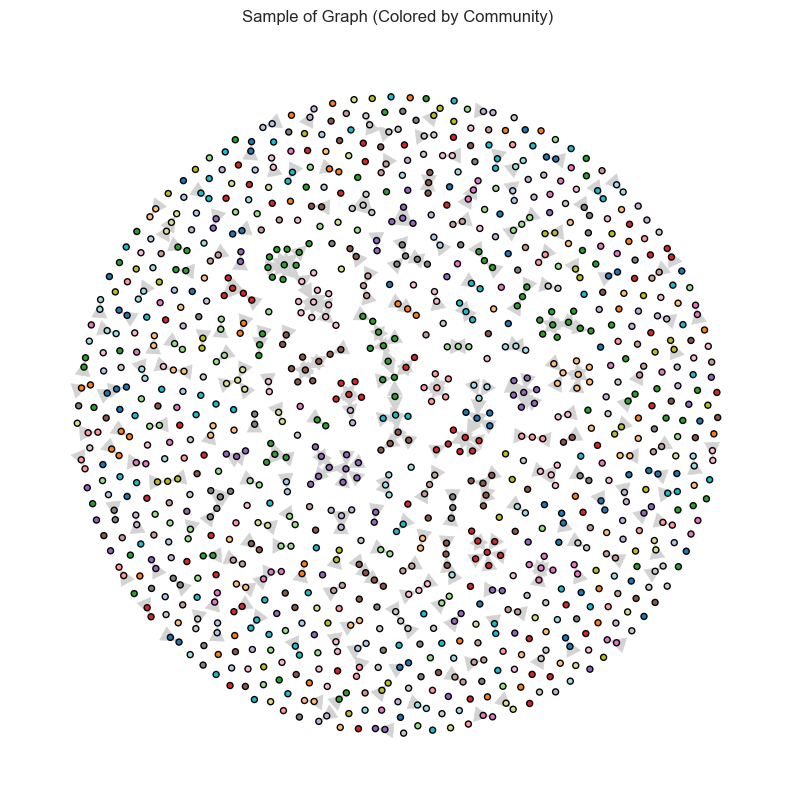

In [176]:
layout = g_sample.layout("fr")
fig, ax = plt.subplots(figsize=(10, 10))

ig.plot(
    g_sample,
    target=ax,
    layout=layout,
    vertex_size=6,
    vertex_color=g_sample.vs["color"],
    edge_width=0.4,
    edge_color="lightgray"
)

plt.title("Sample of Graph (Colored by Community)")
plt.axis("off")
plt.show()
